In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 200
df = pd.DataFrame({
    'time': pd.date_range('2026-03-01', periods=n, freq='s'),
    'temp': np.random.normal(450, 5, n),
    'pressure': np.random.normal(1.0, 0.05, n),
    'vibration': np.random.normal(0.3, 0.1, n)
})
print(df.shape)

#1 결측치 30개를 무작위로 NAN처리
idx = np.random.choice(df.index, 30, replace = False)
df.loc[idx, 'temp'] = np.nan

#2 이상치 5개를 비정상 고온으로
df.loc[df.index[:5], 'temp'] = 9999

#3 중복: 앞 3행을 통째로 복제해 추가
df = pd.concat([df, df.iloc[:3]], ignore_index = True)

#4 자료형 오류 : 압력을 문자열로
df['pressure'] = df['pressure'].astype(str)
df.to_csv('messy.csv', index = False)

# 더러운 데이터 다시 읽기
df = pd.read_csv('messy.csv')
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.describe())

(200, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203 entries, 0 to 202
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   time       203 non-null    object 
 1   temp       174 non-null    float64
 2   pressure   203 non-null    float64
 3   vibration  203 non-null    float64
dtypes: float64(3), object(1)
memory usage: 6.5+ KB
None
time          0
temp         29
pressure      0
vibration     0
dtype: int64
3
              temp    pressure   vibration
count   174.000000  203.000000  203.000000
mean    888.917376    1.004723    0.290483
std    2005.700126    0.049144    0.099296
min     436.901274    0.837937    0.052836
25%     446.475030    0.970010    0.220512
50%     450.340228    1.004850    0.291088
75%     453.742832    1.034410    0.356678
max    9999.000000    1.192637    0.607888


In [ ]:
#결측이 있는 행 전체 삭제
df_drop = df.dropna()

print(len(df), '->', len(df_drop))

df2 = df.dropna(subset = ['temp'])

df3 = df.dropna(axis = 1, thresh = len(df) * 0.5)

203 -> 174


In [7]:
df_mean = df.copy()
df_mean['temp'] = df_mean['temp'].fillna(df_mean['temp'].mean())

df_median = df.copy()
df_median['temp'] = df_median['temp'].fillna(df_median['temp'].median())

df_ffill = df.copy()
df_ffill['temp'] = df_ffill['temp'].ffill()

print("원본 결측치 개수")
print(df['temp'].isnull().sum())

print("평균 대체 후 결측치 개수")
print(df_mean['temp'].isnull().sum())

print("중앙값 대체 후 결측치 개수")
print(df_median['temp'].isnull().sum())

print("ffill 결측치 개수")
print(df_ffill['temp'].isnull().sum())

원본 결측치 개수
29
평균 대체 후 결측치 개수
0
중앙값 대체 후 결측치 개수
0
ffill 결측치 개수
0


In [ ]:
#temp 칼럼에서 결측치는 잠시 제외하고 IQR계산
temp_data = df['temp'].dropna()
Q1 = temp_data.quantile(0.25)
Q3 = temp_data.quantile(0.75)
IQR = Q3 -Q1
low = Q1 - 1.5 * IQR
high = Q3 + 1.5 * IQR
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("정상범위: ", low, "~", high)

mask = (df['temp'] >= low) & (df['temp'] <= high)
df_clean = df[mask]
print("원본 행 개수:", len(df))
print("IQR 이상치 제거 후 행 개수:", len(df_clean))
print("이상치 제거 후 temp 최대값:", df_clean['temp'].max())

Q1: 446.47502968201866
Q3: 453.74283209756965
IQR: 7.267802415550989
정상범위:  435.57332605869215 ~ 464.6445357208961
원본 행 개수: 203
IQR 이상치 제거 후 행 개수: 166
이상치 제거 후 temp 최대값: 463.6008458329481


In [ ]:
# Z-score로 이상치 탐지
temp_data = df['temp'].dropna()
mean = temp_data.mean()
std = temp_data.std()
df_z = df.copy()
df_z['z'] = (df_z['temp'] - mean) / std
df_z_clean = df_z[df_z['z'].abs() <= 3]
df_z_clean = df_z_clean.drop(columns = 'z')
print("Z-score 기준 이상치 제거 후 행 개수:", len(df_z_clean))
print("Z-score 기준 이상치 제거 후 temp 최대값:", df_z_clean['temp'].max())

Z-score 기준 이상치 제거 후 행 개수: 166
Z-score 기준 이상치 제거 후 temp 최대값: 463.6008458329481


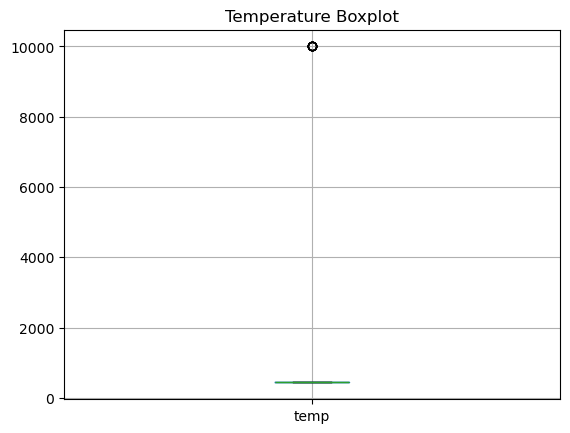

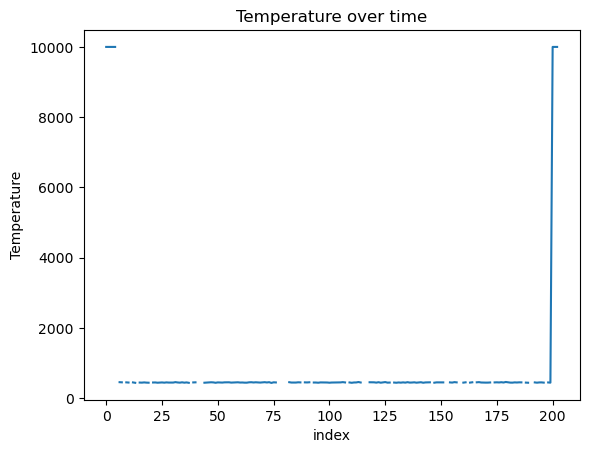

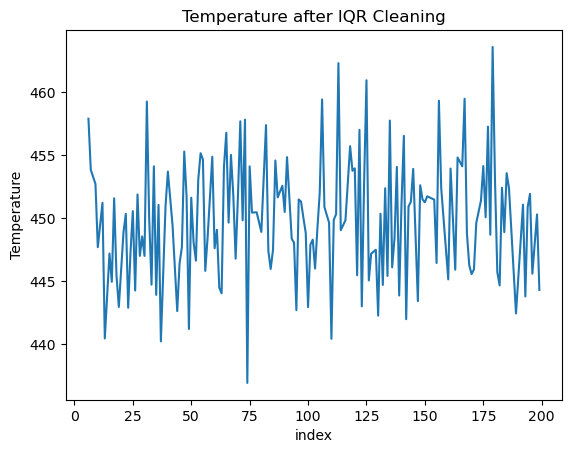

In [ ]:
# 시각화로 이상치 확인
import matplotlib.pyplot as plt
df.boxplot(column='temp')
plt.title('Temperature Boxplot')
plt.show()

# 시계열 선그래프: 9999 지점이 위로 솟구침
df['temp'].plot(title='Temperature over time')
plt.xlabel('index')
plt.ylabel('Temperature')
plt.show()

#이상치 제거 후 다시 확인
df_clean['temp'].plot(title='Temperature after IQR Cleaning')
plt.xlabel('index')
plt.ylabel('Temperature')
plt.show()

In [ ]:
#중복 행 제거
print(df.duplicated().sum())
df = df.drop_duplicates()

# 문자열 -> 숫자변환
df['pressure'] = pd.to_numeric(df['pressure'], errors='coerce')

# answkduf -> 날짜 시간 변환
df['time'] = pd.to_datetime(df['time'])
print(df.dtypes)

3
time         datetime64[ns]
temp                float64
pressure            float64
vibration           float64
dtype: object


C:\Users\user\AppData\Local\Temp\ipykernel_2020\422480393.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pressure'] = pd.to_numeric(df['pressure'], errors='coerce')
C:\Users\user\AppData\Local\Temp\ipykernel_2020\422480393.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['time'] = pd.to_datetime(df['time'])


In [20]:
df_scale = df_clean.copy()

df_scale['temp'] = df_scale['temp'].fillna(df_scale['temp'].median())

c = df_scale['temp']
df_scale['temp_norm'] = (c - c.min()) / (c.max() - c.min())

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cols = ['temp', 'pressure', 'vibration']
df_scale[cols] = scaler.fit_transform(df_scale[cols])
print(df_scale[cols].describe())

               temp      pressure     vibration
count  1.660000e+02  1.660000e+02  1.660000e+02
mean  -4.419490e-15  7.651176e-16 -4.226873e-16
std    1.003026e+00  1.003026e+00  1.003026e+00
min   -2.737424e+00 -3.287637e+00 -2.323154e+00
25%   -7.602115e-01 -7.121452e-01 -7.058844e-01
50%    3.544957e-02  9.944392e-03 -3.190641e-02
75%    5.927532e-01  6.192776e-01  6.645556e-01
max    2.895142e+00  3.771066e+00  3.119881e+00


In [23]:
def clean_pipeline(path):
    df = pd.read_csv(path)
    df['pressure'] = pd.to_numeric(df['pressure'], errors = 'coerce')
    df['time'] = pd.to_datetime(df['time'])
    df = df.drop_duplicates()
    Q1, Q3 = df['temp'].quantile([.25, .75])
    iqr = Q3 - Q1
    df = df[(df['temp'] >= Q1-1.5*iqr) & (df['temp'] <= Q3 + 1.5*iqr)]
    df['temp'] = df['temp'].fillna(df['temp'].median())
    df.to_csv('clean.csv', index = False)
    return df
df = clean_pipeline('messy.csv')

print(df.isnull().sum().sum())
print(df.duplicated().sum())
print(df['temp'].max())
print(df.dtypes)

0
0
463.6008458329481
time         datetime64[ns]
temp                float64
pressure            float64
vibration           float64
dtype: object
